In [1]:
import awkward as ak
import numpy as np
import time
import coffea
import uproot
import hist
import vector
import json
print("awkward version ", ak.__version__)
print("coffea version ", coffea.__version__)
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
from collections import defaultdict
import pickle
import glob
import matplotlib.pyplot as plt

awkward version  1.10.3
coffea version  0.7.21


In [2]:
f = uproot.open('root://cmsxrootd.fnal.gov//store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/130000/1C569D85-60AE-7D43-B42B-6D6FD1D66CC7.root')

In [3]:
f["Events"].keys()

['run',
 'luminosityBlock',
 'event',
 'HTXS_Higgs_pt',
 'HTXS_Higgs_y',
 'HTXS_stage1_1_cat_pTjet25GeV',
 'HTXS_stage1_1_cat_pTjet30GeV',
 'HTXS_stage1_1_fine_cat_pTjet25GeV',
 'HTXS_stage1_1_fine_cat_pTjet30GeV',
 'HTXS_stage1_2_cat_pTjet25GeV',
 'HTXS_stage1_2_cat_pTjet30GeV',
 'HTXS_stage1_2_fine_cat_pTjet25GeV',
 'HTXS_stage1_2_fine_cat_pTjet30GeV',
 'HTXS_stage_0',
 'HTXS_stage_1_pTjet25',
 'HTXS_stage_1_pTjet30',
 'HTXS_njets25',
 'HTXS_njets30',
 'nboostedTau',
 'boostedTau_chargedIso',
 'boostedTau_eta',
 'boostedTau_leadTkDeltaEta',
 'boostedTau_leadTkDeltaPhi',
 'boostedTau_leadTkPtOverTauPt',
 'boostedTau_mass',
 'boostedTau_neutralIso',
 'boostedTau_phi',
 'boostedTau_photonsOutsideSignalCone',
 'boostedTau_pt',
 'boostedTau_puCorr',
 'boostedTau_rawAntiEle2018',
 'boostedTau_rawIso',
 'boostedTau_rawIsodR03',
 'boostedTau_rawMVAnewDM2017v2',
 'boostedTau_rawMVAoldDM2017v2',
 'boostedTau_rawMVAoldDMdR032017v2',
 'boostedTau_charge',
 'boostedTau_decayMode',
 'boostedTau_je

In [4]:
f["Events"]["Generator_binvar"].arrays()

<Array [{Generator_binvar: 29.3, ... ] type='1596000 * {"Generator_binvar": floa...'>

In [5]:
fileset = {"2016":[], "2016APV":[]}

with open('data/nanoAOD/QCD.json') as json_file:
    data = json.load(json_file)
    fileset['2016'] += ['root://cmsxrootd//'+data['2016'][i] for i in range(len(data))]
    fileset['2016APV'] += ['root://cmsxrootd//'+data['2016APV'][i] for i in range(len(data))]
print(fileset)

{'2016': ['root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/130000/1C569D85-60AE-7D43-B42B-6D6FD1D66CC7.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/130000/2EDCC683-1B4B-614B-BEB7-D80BBC20AD8E.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/19E8D842-3175-1449-AF6C-FD9C69D12724.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/3957434B-7E09-3B4C-8329-FD44D82C7DB7.root', 'root://cmsxrootd///store/mc/RunIISummer20UL16NanoAODv9/QCD_Pt-15to7000_TuneCP5_Flat2018_13TeV_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/397D1673-167A-CF46-9E79-D7069D9AC359.root'], '2016APV': ['r

In [64]:
class Counter(processor.ProcessorABC):
    def __init__(self ):
        weights_axis = hist.axis.Regular(100, -30, 0, name="w", label="Weights")
        pt_axis = hist.axis.Regular( 700, 0, 7000, 
                                     name="pt", label="Pt")

#        pt_axis = hist.axis.Variable( [0,10,20,30,40,50,60,70,80,90,
#                                       100,110,120,130,140,150,160,170,180,190,
#                                       200,210,220,230,240,250,260,270,280,290,
#                                       300,310,320,330,340,350,360,370,380,390,
#                                       400,410,420,430,440,450,460,470,480,490,
#                                       500,510,520,530,540,550,560,570,580,590,
#                                       1000,2000,3000,4000,5000,6000,7000], 
#                                     name="pt", label="Pt")
        dataset_axis = hist.axis.StrCategory([], growth=True, name="dataset", label="Primary dataset")
        
        ### Plots of things during the selection process / for debugging with fine binning
        h_w = hist.Hist(dataset_axis, weights_axis, pt_axis, storage="weight", label="Counts")
        self.hists = {
            "w":h_w
        }
        
        self.means_stddevs = defaultdict()
    
    @property
    def accumulator(self):
        return self.hists

    
    # we will receive a NanoEvents instead of a coffea DataFrame
    def process(self, events):
        dataset = events.metadata['dataset']
        
        ht = ak.sum( events["Jet"].pt, axis=1 )
        htgood = ht > 1400.
        events = events[htgood]
        
        avg = np.average(events.genWeight)
        stddev = np.std(events.genWeight)

        #print("weights ", np.log(events["Generator"].weight))
        #print("binvar  ", events["Generator"].binvar)
        self.hists['w'].fill( dataset=dataset, w=np.log(events["Generator"].weight)/np.log(10.), pt=events["Generator"].binvar )
        weirdweight = ((events["Generator"].weight - avg) / stddev > 2)

        weird = weirdweight
        
        print(events["Generator"].weight[weird] )
        print(events["Generator"].binvar[weird] )
                
        return self.hists

    
    def postprocess(self, accumulator):
        return accumulator
    
    
    

In [65]:
run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=2),
    schema=NanoAODSchema,
    chunksize=1000000,
    maxchunks=None
)

output = run(
    fileset,
    "Events",
    processor_instance=Counter(),
)

Output()

[1.53e-07, 7.86e-08, 1.78e-07, 1.36e-07, ... 1.05e-07, 2.47e-07, 2.7e-07, 2.09e-07]
[514, 582, 499, 526, 428, 552, 391, 580, ... 331, 507, 554, 579, 552, 469, 461, 484]
[1.81e-07, 4.29e-07, 7.45e-08, 1.77e-07, ... 1.84e-07, 1.24e-07, 2.48e-07, 1.89e-07]
[498, 421, 588, 500, 504, 560, 528, 542, ... 491, 583, 579, 567, 496, 535, 469, 494]
[0.00348]
[50.3]
[5.38e-07, 9.01e-08, 1.72e-07, 8.66e-08, ... 6.94e-08, 1.03e-07, 2.01e-07, 1.04e-07]
[402, 567, 503, 572, 498, 580, 456, 511, ... 593, 533, 570, 598, 595, 554, 488, 552]
[1.41e-07, 8.71e-07, 4.95e-07, 9.54e-08, ... 7.11e-07, 1.13e-07, 1.87e-07, 8.38e-08]
[522, 365, 409, 561, 540, 356, 543, 574, ... 578, 546, 559, 396, 380, 544, 495, 575]
[8.16e-08, 8.47e-08, 2.03e-07, 7.2e-08, ... 3.76e-07, 4.64e-07, 8.97e-08, 1.51e-07]
[578, 574, 487, 591, 530, 518, 383, 527, ... 560, 464, 560, 544, 432, 414, 568, 515]
[9.1e-08, 9.66e-08, 5.92e-08, 5.42e-07, ... 1.34e-07, 6.23e-08, 7.43e-08, 8.62e-08]
[566, 560, 613, 402, 483, 559, 562, 542, 554, 569, 

In [66]:
output

{'w': Hist(
   StrCategory(['2016APV', '2016'], growth=True, name='dataset', label='Primary dataset'),
   Regular(100, -30, 0, name='w', label='Weights'),
   Regular(700, 0, 7000, name='pt', label='Pt'),
   storage=Weight()) # Sum: WeightedSum(value=1.90722e+06, variance=1.90722e+06)}

In [67]:
w, x, y = output['w'][0,:,:].to_numpy()
print(x)

[-3.00e+001 -2.97e+001 -2.94e+001 -2.91e+001 -2.88e+001 -2.85e+001
 -2.82e+001 -2.79e+001 -2.76e+001 -2.73e+001 -2.70e+001 -2.67e+001
 -2.64e+001 -2.61e+001 -2.58e+001 -2.55e+001 -2.52e+001 -2.49e+001
 -2.46e+001 -2.43e+001 -2.40e+001 -2.37e+001 -2.34e+001 -2.31e+001
 -2.28e+001 -2.25e+001 -2.22e+001 -2.19e+001 -2.16e+001 -2.13e+001
 -2.10e+001 -2.07e+001 -2.04e+001 -2.01e+001 -1.98e+001 -1.95e+001
 -1.92e+001 -1.89e+001 -1.86e+001 -1.83e+001 -1.80e+001 -1.77e+001
 -1.74e+001 -1.71e+001 -1.68e+001 -1.65e+001 -1.62e+001 -1.59e+001
 -1.56e+001 -1.53e+001 -1.50e+001 -1.47e+001 -1.44e+001 -1.41e+001
 -1.38e+001 -1.35e+001 -1.32e+001 -1.29e+001 -1.26e+001 -1.23e+001
 -1.20e+001 -1.17e+001 -1.14e+001 -1.11e+001 -1.08e+001 -1.05e+001
 -1.02e+001 -9.90e+000 -9.60e+000 -9.30e+000 -9.00e+000 -8.70e+000
 -8.40e+000 -8.10e+000 -7.80e+000 -7.50e+000 -7.20e+000 -6.90e+000
 -6.60e+000 -6.30e+000 -6.00e+000 -5.70e+000 -5.40e+000 -5.10e+000
 -4.80e+000 -4.50e+000 -4.20e+000 -3.90e+000 -3.60e+000 -3.30e

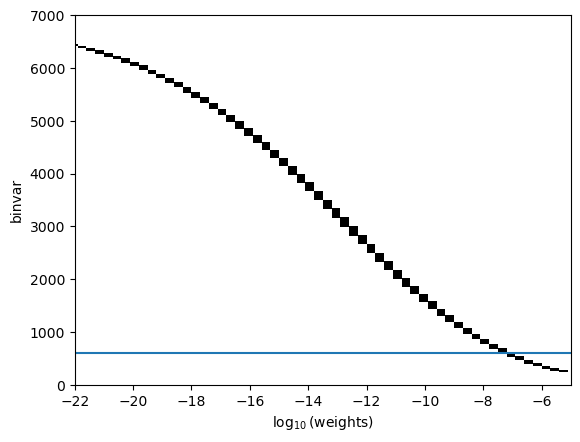

In [80]:
mesh = plt.pcolormesh(x,y, w.T, cmap="Greys", vmin=1e-8, vmax=1e-3 )
# plt.ylim(0,700)
plt.xlim(-22,-5)
plt.xlabel(r'$\log_{10}\left(\mathrm{weights}\right)$')
plt.ylabel('binvar')
plt.axline((-22, 600), (-5, 600))
# plt.xscale('symlog')

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f5355314460>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

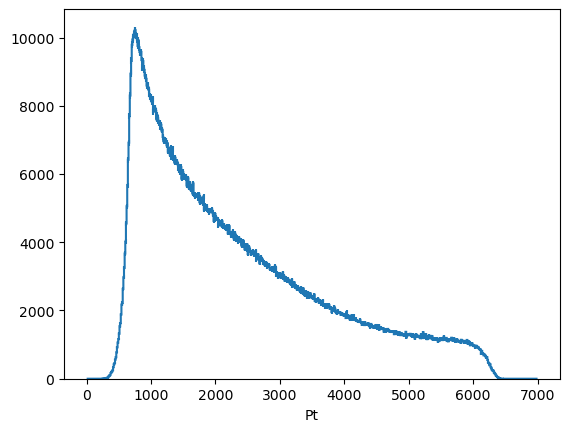

In [40]:
output['w'].project("pt").plot()
#plt.yscale("log")
#plt.xlim(0,1000)